In [11]:
"""
Write a Python program to draw a 3D plot that visualizes the regression model for house price prediction using suitable Python-based 3D plotting libraries.

Assume the following features were used:
Area (sq ft)
Number of Bedrooms
House Price
"""

'\nWrite a Python program to draw a 3D plot that visualizes the regression model for house price prediction using suitable Python-based 3D plotting libraries.\n\nAssume the following features were used:\nArea (sq ft)\nNumber of Bedrooms\nHouse Price\n'

In [9]:
import pandas as pd

dataset_file = 'ps-4.csv'

# Prepare the dataset
try:
    df = pd.read_csv(dataset_file)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("File not found!")

df.head()

Dataset loaded successfully.


,Area (sq ft),Number of Bedrooms,House Price
0,1790,2,114300
1,2030,4,114200
2,1740,3,114800
3,1980,3,94700
4,2130,3,119800


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Fit the Linear Regression Model
X = df[['Area (sq ft)', 'Number of Bedrooms']]
y = df['House Price']

## Did not scale the data here

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


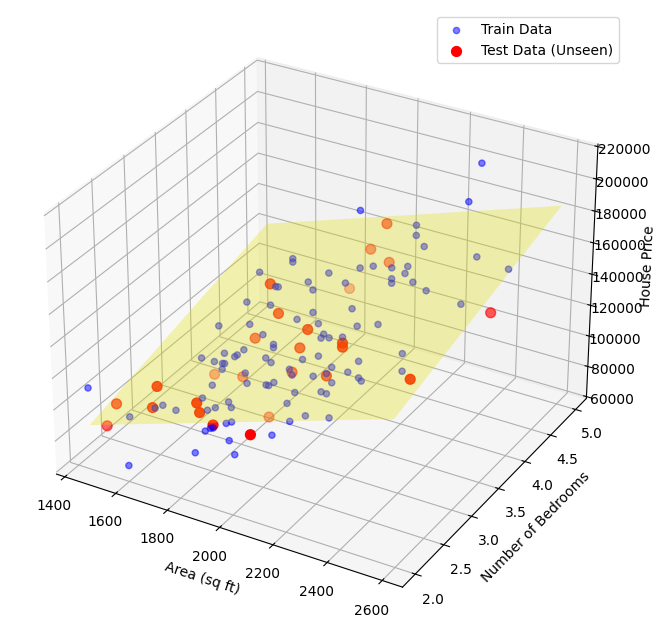

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Visualization and plot Data Points
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_train['Area (sq ft)'], X_train['Number of Bedrooms'], y_train, color='blue', alpha=0.5, label='Train Data')
ax.scatter(X_test['Area (sq ft)'], X_test['Number of Bedrooms'], y_test, color='red', s=50, label='Test Data (Unseen)')

# Plot the Regression Plane
a_range = np.linspace(X['Area (sq ft)'].min(), X['Area (sq ft)'].max(), 20)
b_range = np.linspace(X['Number of Bedrooms'].min(), X['Number of Bedrooms'].max(), 20)

A, B = np.meshgrid(a_range, b_range)
P = model.predict(np.c_[A.ravel(), B.ravel()]).reshape(A.shape)

ax.plot_surface(A, B, P, color='yellow', alpha=0.3)

# labels
ax.set_xlabel('Area (sq ft)')
ax.set_ylabel('Number of Bedrooms')
ax.set_zlabel('House Price')
plt.legend()
plt.show()